### Risk Adjusted Returns


In [15]:
import pandas as pd
import numpy as np

prices = pd.read_csv("../labs/data/sample_prices.csv")
returns = prices.pct_change().dropna()
returns.head()

,BLUE,ORANGE
1,0.023621,0.039662
2,-0.021807,-0.033638
3,-0.031763,0.082232
4,0.034477,0.044544
5,0.037786,-0.026381


In [16]:
returns.std() * np.sqrt(12)

BLUE      0.083060
ORANGE    0.275747
dtype: float64

In [17]:
portfolio_returns = pd.read_csv(
    "../labs/data/Portfolios_Formed_on_ME_monthly_EW.csv",
    header=0,
    index_col=0,
    parse_dates=True,
    na_values=-99.99,
)
portfolio_returns.head()

C:\Users\beall\AppData\Local\Temp\ipykernel_14696\2203812934.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  portfolio_returns = pd.read_csv(


,<= 0,Lo 30,Med 40,Hi 30,Lo 20,Qnt 2,Qnt 3,Qnt 4,Hi 20,Lo 10,Dec 2,Dec 3,Dec 4,Dec 5,Dec 6,Dec 7,Dec 8,Dec 9,Hi 10
192607,NaN,-0.43,1.52,2.68,-0.57,0.59,1.60,1.47,3.33,-1.45,0.29,-0.15,1.33,1.24,1.98,1.55,1.38,3.38,3.29
192608,NaN,3.90,3.04,2.09,3.84,3.59,3.71,1.61,2.33,5.12,2.59,4.03,3.15,2.72,4.72,1.60,1.63,0.98,3.70
192609,NaN,-1.08,-0.54,0.16,-0.48,-1.40,0.00,-0.50,-0.09,0.93,-1.87,-2.27,-0.53,0.07,-0.07,-1.64,0.64,-0.86,0.67
192610,NaN,-3.32,-3.52,-3.06,-3.29,-4.10,-2.89,-3.36,-2.95,-4.84,-1.77,-3.36,-4.83,-2.98,-2.80,-3.45,-3.27,-3.47,-2.43
192611,NaN,-0.46,3.82,3.09,-0.55,2.18,3.41,3.39,3.16,-0.78,-0.32,-0.29,4.65,3.24,3.57,3.82,2.95,3.61,2.70


In [ ]:
# Convert YYYYMM format to clean datetime periods
portfolio_returns.index = pd.to_datetime(
    portfolio_returns.index, format="%Y%m"
).to_period("M")

In [19]:
columns = ["Lo 20", "Hi 20"]
returns = portfolio_returns[columns]
returns.head()

,Lo 20,Hi 20
1926-07,-0.57,3.33
1926-08,3.84,2.33
1926-09,-0.48,-0.09
1926-10,-3.29,-2.95
1926-11,-0.55,3.16


In [20]:
returns = returns / 100
returns.head()

,Lo 20,Hi 20
1926-07,-0.0057,0.0333
1926-08,0.0384,0.0233
1926-09,-0.0048,-0.0009
1926-10,-0.0329,-0.0295
1926-11,-0.0055,0.0316


In [21]:
returns.columns = ["Lo 20", "Hi 20"]
returns.head()

,Lo 20,Hi 20
1926-07,-0.0057,0.0333
1926-08,0.0384,0.0233
1926-09,-0.0048,-0.0009
1926-10,-0.0329,-0.0295
1926-11,-0.0055,0.0316


<Axes: >

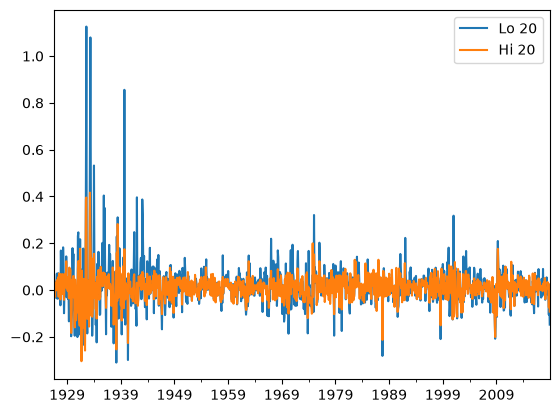

In [22]:
returns.plot()

In [23]:
returns.std()

Lo 20    0.097197
Hi 20    0.056325
dtype: float64

In [24]:
annualized_volatility = returns.std() * np.sqrt(12)
annualized_volatility

Lo 20    0.336701
Hi 20    0.195116
dtype: float64

In [25]:
# return_per_month = (returns + 1).prod() ** (1 / len(returns)) - 1
# return_per_month

In [26]:
annualized_volatility

Lo 20    0.336701
Hi 20    0.195116
dtype: float64

In [27]:
# annualized_return = (return_per_month + 1) ** 12 - 1
# annualized_return

In [ ]:
# Find the annualized return from 1999 - 2015, inclusive

annualized_return = (returns.loc["1999":"2015"] + 1).prod() ** (
    1 / len(returns.loc["1999":"2015"])
) - 1
annualized_return = (annualized_return + 1) ** 12 - 1
annualized_return

Lo 20    0.114426
Hi 20    0.062865
dtype: float64

In [ ]:
# Find the annualized volatility from 1999 - 2015, inclusive
annualized_volatility = returns.loc["1999":"2015"].std() * (12**0.5)
annualized_volatility

Lo 20    0.228894
Hi 20    0.172713
dtype: float64

In [30]:
annualized_return / annualized_volatility

Lo 20    0.499909
Hi 20    0.363985
dtype: float64

In [31]:
risk_free_rate = 0.03
excess_return = annualized_return - risk_free_rate
sharpe_ratio = excess_return / annualized_volatility
sharpe_ratio

Lo 20    0.368844
Hi 20    0.190287
dtype: float64

In [45]:
# 1. Isolate the time period first
returns_99_15 = returns.loc["1999":"2015"]

# 2. Build a daily/monthly wealth index (tracking a $1,000 investment)
wealth_index = 1000 * (1 + returns_99_15).cumprod()

# 3. Track the highest peak the wealth index had achieved up to each point in time
previous_peaks = wealth_index.cummax()

# 4. Calculate the drawdown at every single point in time
drawdowns = (wealth_index - previous_peaks) / previous_peaks

# 5. Find the Maximum Drawdown (the lowest value in the drawdowns series)
max_drawdown = drawdowns.min()

print(max_drawdown)

Lo 20   -0.624809
Hi 20   -0.552735
dtype: float64


In [ ]:
# Max drawdown 1999 - 2015

# 1. Slice the time-series first
returns_99_15 = returns.loc["1999":"2015"]

# 2. Compute a running Wealth Index (assume a $1,000 starting investment)
wealth_index = 1000 * (1 + returns_99_15).cumprod()

# 3. Compute the running historical peaks
previous_peaks = wealth_index.cummax()

# 4. Compute the drawdown at every single month
drawdowns = (wealth_index - previous_peaks) / previous_peaks

# 5. Find the exact month (index) where the drawdown was at its lowest point
max_drawdown_months = drawdowns.idxmin()

print(max_drawdown_months)

Lo 20    2009-02
Hi 20    2009-02
dtype: period[M]


In [38]:
hfi = pd.read_csv(
    "../labs/data/edhec-hedgefundindices.csv",
    header=0,
    index_col=0,
    parse_dates=True,
    na_values=-99.99,
)

hfi.head()

C:\Users\beall\AppData\Local\Temp\ipykernel_14696\904169306.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  hfi = pd.read_csv(


,Convertible Arbitrage,CTA Global,Distressed Securities,Emerging Markets,Equity Market Neutral,Event Driven,Fixed Income Arbitrage,Global Macro,Long/Short Equity,Merger Arbitrage,Relative Value,Short Selling,Funds Of Funds
date,,,,,,,,,,,,,
1997-01-31,1.19,3.93,1.78,7.91,1.89,2.13,1.91,5.73,2.81,1.50,1.80,-1.66,3.17
1997-02-28,1.23,2.98,1.22,5.25,1.01,0.84,1.22,1.75,-0.06,0.34,1.18,4.26,1.06
1997-03-31,0.78,-0.21,-0.12,-1.20,0.16,-0.23,1.09,-1.19,-0.84,0.60,0.10,7.78,-0.77
1997-04-30,0.86,-1.70,0.30,1.19,1.19,-0.05,1.30,1.72,0.84,-0.01,1.22,-1.29,0.09
1997-05-31,1.56,-0.15,2.33,3.15,1.89,3.46,1.18,1.08,3.94,1.97,1.73,-7.37,2.75


In [40]:
# Which hfi index has the highest semideviation from 2009 - 2018?

hfi_semideviation = hfi.loc["2009":"2018"]
hfi_semideviation = hfi_semideviation[hfi_semideviation < 0].std()
hfi_semideviation.idxmax()

'Short Selling'

In [42]:
# Which hfi index has the lowest semideviation from 2009 - 2018?
hfi_semideviation.idxmin()

'Fixed Income Arbitrage'

In [43]:
# Which hedge fund strategy has been the most negatively skewed in 2009?
hfi_skew_2009 = hfi.loc["2009"].skew()
hfi_skew_2009.idxmin()

'Merger Arbitrage'

In [44]:
# Which hedge fund stragegy has the highest kurtosis from 2000 - 2018?
hfi_kurtosis = hfi.loc["2000":"2018"].kurtosis()
hfi_kurtosis.idxmax()

'Fixed Income Arbitrage'